In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('spam.csv')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df=df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1)
df=df.rename(columns={'v1':'label','v2':'Text'})
df.head()

,label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


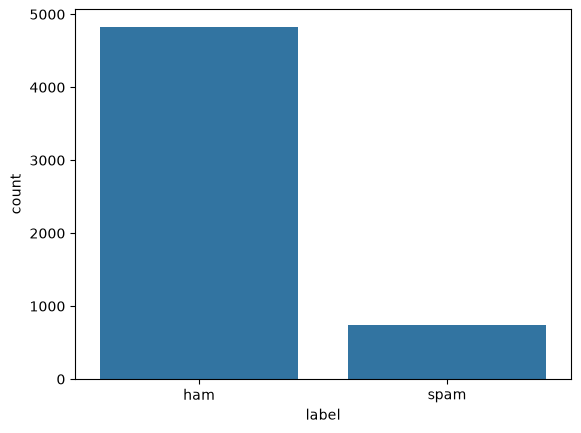

In [4]:
sns.countplot(data=df,x='label')
plt.show()

In [5]:
ham_ms=df[df['label']=='ham']
spam_ms=df[df['label']=='spam']
ham_balanced=ham_ms.sample(n=len(spam_ms),random_state=42)
balanced_dataset=pd.concat([ham_balanced,spam_ms]).reset_index(drop=True)
balanced_dataset

,label,Text
0,ham,If i not meeting Ã¼ all rite then i'll go home...
1,ham,"I.ll always be there, even if its just in spir..."
2,ham,"Sorry that took so long, omw now"
3,ham,I thk 50 shd be ok he said plus minus 10.. Did...
4,ham,Dunno i juz askin cos i got a card got 20% off...
...,...,...
1489,spam,Want explicit SEX in 30 secs? Ring 02073162414...
1490,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
1491,spam,Had your contract mobile 11 Mnths? Latest Moto...
1492,spam,REMINDER FROM O2: To get 2.50 pounds free call...


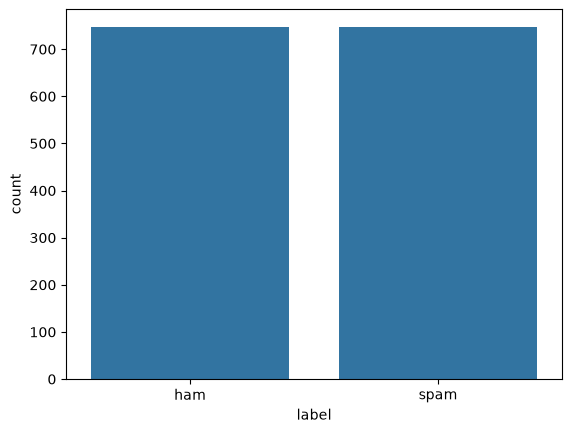

In [6]:
sns.countplot(data=balanced_dataset,x='label')
plt.show()

In [7]:
import string
punctuations_list=string.punctuation
def remove_punctuations(text:str):
    temp=str.maketrans('','',punctuations_list)
    return text.translate(temp)


balanced_dataset['Text']=balanced_dataset['Text'].map(remove_punctuations)
balanced_dataset.head()

,label,Text
0,ham,If i not meeting Ã¼ all rite then ill go home ...
1,ham,Ill always be there even if its just in spirit...
2,ham,Sorry that took so long omw now
3,ham,I thk 50 shd be ok he said plus minus 10 Did Ã...
4,ham,Dunno i juz askin cos i got a card got 20 off ...


In [8]:
from nltk.corpus import stopwords
stop_words=stopwords.words('english')
def remove_stop_words(text):
    final=[]
    for word in text.split():
        word=word.lower()
        if word not in stop_words:
            final.append(word)
    return " ".join(final)

balanced_dataset['Text']=balanced_dataset['Text'].map(remove_stop_words)
balanced_dataset.head()

,label,Text
0,ham,meeting ã¼ rite ill go home lor ã¼ dun feel li...
1,ham,ill always even spirit ill get bb soon trying ...
2,ham,sorry took long omw
3,ham,thk 50 shd ok said plus minus 10 ã¼ leave line...
4,ham,dunno juz askin cos got card got 20 4 salon ca...


In [9]:
balanced_dataset['label']=balanced_dataset['label'].map({"ham":0,"spam":1})
balanced_dataset.head()

,label,Text
0,0,meeting ã¼ rite ill go home lor ã¼ dun feel li...
1,0,ill always even spirit ill get bb soon trying ...
2,0,sorry took long omw
3,0,thk 50 shd ok said plus minus 10 ã¼ leave line...
4,0,dunno juz askin cos got card got 20 4 salon ca...


In [10]:
balanced_dataset.to_csv('cleaned_data.csv',index=False)